In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ratings = pd.read_csv('./ml-32m/ratings.csv')
movies = pd.read_csv('./ml-32m/movies.csv')
ratings.head(5)

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [3]:
print(ratings['userId'].unique().shape[0])
print(ratings['movieId'].unique().shape[0])
ratings.isna().sum()


200948
84432


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [4]:
ratings['userId'].value_counts()

userId
175325    33332
17035      9577
55653      9178
123465     9044
171795     9016
          ...  
200827       20
200854       20
200867       20
200900       20
200927       20
Name: count, Length: 200948, dtype: int64

In [5]:
ratings['userId']

0                1
1                1
2                1
3                1
4                1
             ...  
32000199    200948
32000200    200948
32000201    200948
32000202    200948
32000203    200948
Name: userId, Length: 32000204, dtype: int64

In [6]:
ratings['movieId'].unique()

array([    17,     25,     29, ..., 175771, 157917, 274343],
      shape=(84432,))

In [7]:
from scipy.sparse import csr_matrix

user_cat = ratings['userId'].astype('category')
movie_cat = ratings['movieId'].astype('category')

userId = user_cat.cat.codes
movieId = movie_cat.cat.codes

user_index_to_id = dict(enumerate(user_cat.cat.categories))
movie_index_to_id = dict(enumerate(movie_cat.cat.categories))

x = csr_matrix(
    (ratings['rating'], (userId,movieId))
)
print(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 32000204 stored elements and shape (200948, 84432)>
  Coords	Values
  (0, 16)	4.0
  (0, 24)	1.0
  (0, 28)	2.0
  (0, 29)	5.0
  (0, 31)	5.0
  (0, 33)	2.0
  (0, 35)	1.0
  (0, 79)	5.0
  (0, 108)	3.0
  (0, 109)	5.0
  (0, 159)	1.0
  (0, 164)	5.0
  (0, 174)	4.0
  (0, 220)	3.0
  (0, 229)	5.0
  (0, 257)	5.0
  (0, 298)	4.0
  (0, 302)	5.0
  (0, 303)	5.0
  (0, 318)	4.0
  (0, 340)	1.0
  (0, 351)	2.0
  (0, 522)	3.0
  (0, 536)	5.0
  (0, 555)	5.0
  :	:
  (200947, 11699)	4.5
  (200947, 11701)	4.0
  (200947, 11702)	2.0
  (200947, 11733)	4.5
  (200947, 11759)	4.5
  (200947, 11813)	2.0
  (200947, 11856)	4.5
  (200947, 11975)	4.5
  (200947, 11984)	5.0
  (200947, 12102)	0.5
  (200947, 12105)	3.5
  (200947, 12147)	1.5
  (200947, 12182)	2.0
  (200947, 12324)	4.5
  (200947, 12425)	4.0
  (200947, 13903)	4.5
  (200947, 14099)	5.0
  (200947, 14333)	4.5
  (200947, 14473)	5.0
  (200947, 14806)	3.0
  (200947, 15050)	4.5
  (200947, 15069)	1.0
  (200947, 15

In [8]:
x.shape

(200948, 84432)

In [9]:
user_sum = np.array(x.sum(axis =  1)).flatten()
user_count = np.diff(x.indptr)
mu = user_sum/user_count

x_centered = x.copy()
for i in range(x.shape[0]):
    start,end = x.indptr[i],x.indptr[i+1]
    x_centered.data[start:end] -= mu[i]


In [10]:
from scipy.sparse.linalg import svds
k = 200
U, S, VT = svds(x_centered, k=k)

In [11]:
S

array([ 139.91846671,  140.22798455,  140.53872833,  140.60132443,
        140.90853238,  140.94607791,  141.23575475,  141.28560005,
        141.40045417,  141.70174956,  141.81073158,  141.9446268 ,
        142.13536213,  142.53858459,  142.61816485,  142.93993505,
        143.23323481,  143.3161023 ,  143.41592069,  143.65952457,
        143.81952416,  144.11175845,  144.19592489,  144.46238683,
        144.60995291,  144.8527731 ,  145.00358643,  145.38583735,
        145.55508724,  145.94789981,  146.012654  ,  146.24493087,
        146.45384076,  146.68123489,  146.80607025,  147.06953013,
        147.4895485 ,  147.55541775,  147.63707724,  147.95590158,
        148.30743702,  148.42412826,  148.71207376,  149.01718736,
        149.20174401,  149.54672222,  149.65843643,  150.06951934,
        150.38094921,  150.51743574,  150.93566367,  151.21357377,
        151.46336451,  151.62963408,  152.25566228,  152.44512028,
        152.77909151,  152.94721893,  153.21744171,  153.64302

In [12]:
idx = np.array(sorted((range(k)),reverse=True))
S = S[idx]
U = U[:, idx]
VT = VT[idx, :]

In [13]:
user_emb = U @ np.diag(S)
movie_emb = VT.T

In [14]:
sample = ((user_emb[0] @ movie_emb.T)+mu[0])
np.argsort(sample)[::-1][:10]

array([ 109, 1182, 1177,  257, 1655,   31, 2305, 1237, 1166,  536])

In [15]:
x.indptr[1]-x.indptr[0]

np.int32(141)

In [16]:
def getMovieIds(rec):
    Ids = np.zeros((rec.shape[0]))
    for i,idx in enumerate(rec):
        Ids[i] = movie_index_to_id[idx]
        # print(i,idx)
    return Ids

def getNameFromId(id):
    return movies[movies['movieId'] == id].title

def recommend(user_idx, top_n=10):
    scores = user_emb[user_idx] @ movie_emb.T
    scores += mu[user_idx]
    start, end = x.indptr[user_idx], x.indptr[user_idx+1]
    rated_items = x.indices[start:end]
    scores[rated_items] = -np.inf
    top_items = np.argsort(scores)[::-1][:top_n]
    top_movie_ids = getMovieIds(top_items)
    return top_movie_ids

In [17]:
sample = recommend(678)
for id in sample:
    print(getNameFromId(id))

11119    Pan's Labyrinth (Laberinto del fauno, El) (2006)
Name: title, dtype: str
3924    O Brother, Where Art Thou? (2000)
Name: title, dtype: str
11126    Departed, The (2006)
Name: title, dtype: str
12759    Slumdog Millionaire (2008)
Name: title, dtype: str
1591    Gattaca (1997)
Name: title, dtype: str
17679    Intouchables (2011)
Name: title, dtype: str
2826    Ferris Bueller's Day Off (1986)
Name: title, dtype: str
4204    Moulin Rouge (2001)
Name: title, dtype: str
14338    Shutter Island (2010)
Name: title, dtype: str
10115    Serenity (2005)
Name: title, dtype: str


In [18]:
user_id_to_index ={
    id: idx
    for idx,id in user_index_to_id.items()
}
movie_id_to_index = {
    id: idx
    for idx,id in movie_index_to_id.items()
}

In [19]:
def coldStart(new_user_ratings):
    items = []
    vals = []
    for mId, rat in new_user_ratings.items():
        if mId in movie_id_to_index:
            items.append(movie_id_to_index[mId])
            vals.append(rat)

    vals = np.array(vals)
    mu = vals.mean()
    vals_centered = vals - mu
    

    p_new = np.zeros(movie_emb.shape[1])
    
    for idx, rc in zip(items, vals_centered):
        p_new += rc * movie_emb[idx]
    
    pred = p_new @ movie_emb.T + mu
    for i in items:
        pred[i] = -np.inf
    return pred
def recommendNew(new_user_ratings,top_n = 10):
    pred = coldStart(new_user_ratings)
    top = np.argsort(pred)[::-1][:top_n]
    top_ids = [movie_index_to_id[i] for i in top]
    return top_ids

data = dict({
    195159:5,
    109487:3,
    2571:3,
    166024:4,
    5618:5,
    48780:3,
    48561:4,
    7153:4,
    4896:5, #
    8368:5, #
    5816:5 #
})

rec = recommendNew(data, top_n= 20)
for ids in rec:
    print(movies[movies.movieId == ids].title)

10410    Harry Potter and the Goblet of Fire (2005)
Name: title, dtype: str
2908    Princess Mononoke (Mononoke-hime) (1997)
Name: title, dtype: str
9595    Howl's Moving Castle (Hauru no ugoku shiro) (2...
Name: title, dtype: str
5860    My Neighbor Totoro (Tonari no Totoro) (1988)
Name: title, dtype: str
11702    Harry Potter and the Order of the Phoenix (2007)
Name: title, dtype: str
352    Four Weddings and a Funeral (1994)
Name: title, dtype: str
6975    Nausicaä of the Valley of the Wind (Kaze no ta...
Name: title, dtype: str
3525    Mission: Impossible II (2000)
Name: title, dtype: str
25087    Mad Max: Fury Road (2015)
Name: title, dtype: str
6239    Laputa: Castle in the Sky (Tenkû no shiro Rapy...
Name: title, dtype: str
8923    Kiki's Delivery Service (Majo no takkyûbin) (1...
Name: title, dtype: str
102    Happy Gilmore (1996)
Name: title, dtype: str
13513    Harry Potter and the Half-Blood Prince (2009)
Name: title, dtype: str
21176    Grand Budapest Hotel, The (2014)
Name

In [20]:
np.savez(
    "recommender_model.npz",
    movie_emb=movie_emb,
    movie_ids=np.array(list(movie_id_to_index.keys())),
    movie_indices=np.array(list(movie_id_to_index.values()))
)

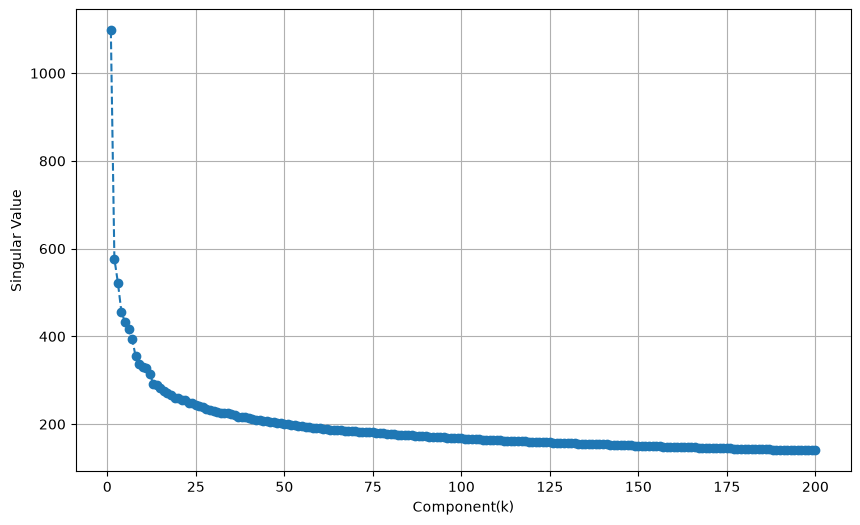

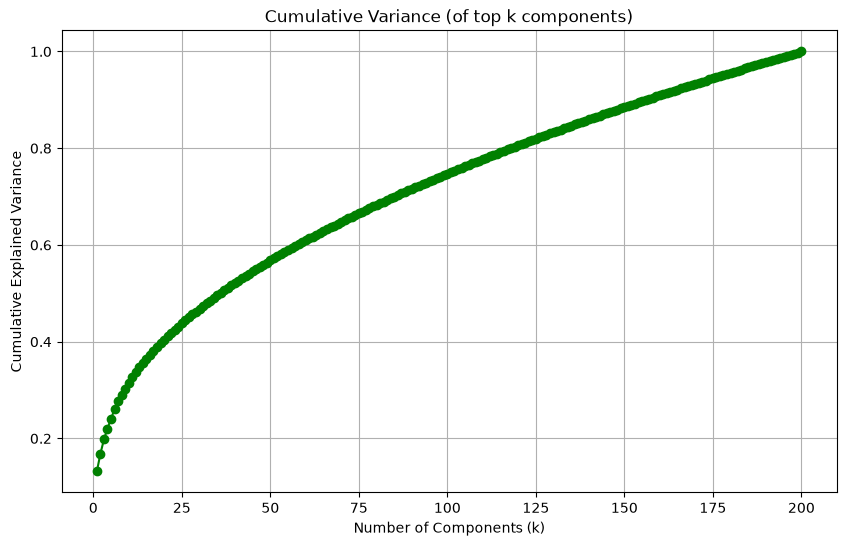

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(S) + 1), S, marker='o', linestyle='--')
plt.xlabel('Component(k)')
plt.ylabel('Singular Value')
plt.grid(True)
plt.show()

explained_variance = (S ** 2) / np.sum(S ** 2)
cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(S) + 1), cumulative_variance, marker='o', color='green')
plt.title('Cumulative Variance (of top k components)')
plt.xlabel('Number of Components (k)')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


RMSE for k=10: 0.8714
RMSE for k=20: 0.8531
RMSE for k=50: 0.8211
RMSE for k=80: 0.7987
RMSE for k=100: 0.7862
RMSE for k=150: 0.7596
RMSE for k=200: 0.7369


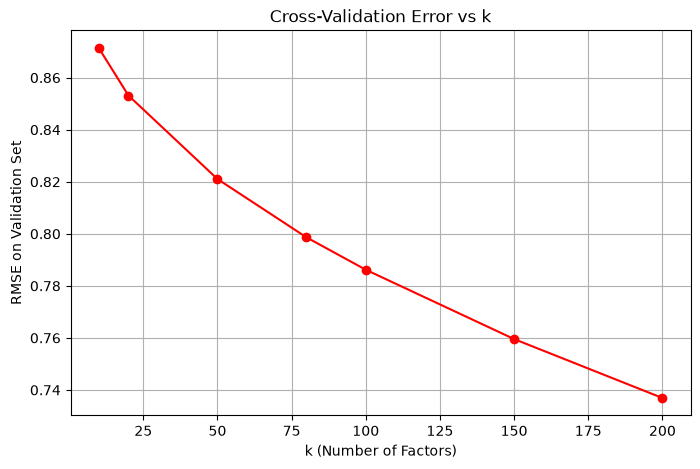

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
import random

def evaluate_k_svd(x_centered, k_values=[10,20,50,80,100,150,200]):
    non_zero_rows, non_zero_cols = x_centered.nonzero()
    num_non_zeros = len(non_zero_rows)
    val_size = int(num_non_zeros * 0.05)
    val_indices = np.random.choice(num_non_zeros, val_size, replace=False)
    
    val_rows = non_zero_rows[val_indices]
    val_cols = non_zero_cols[val_indices]
    
    actual_ratings = np.array(x_centered[val_rows, val_cols]).flatten()
    
    errors = []
    

    for k in k_values:
        U, S_val, VT = svds(x_centered, k=k)
        idx = np.argsort(S_val)[::-1]
        S_val = S_val[idx]
        U = U[:, idx]
        VT = VT[idx, :]
        
        predictions = []
        user_emb = U * S_val
        movie_emb = VT.T
        
        for r, c in zip(val_rows, val_cols):
            pred = np.dot(user_emb[r], movie_emb[c])
            predictions.append(pred)
            
        rmse = sqrt(mean_squared_error(actual_ratings, predictions))
        errors.append(rmse)
        print(f"RMSE for k={k}: {rmse:.4f}")
        
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, errors, marker='o', color='red')
    plt.xlabel('k')
    plt.ylabel('RMSE on Validation Set')
    plt.grid(True)
    plt.show()

evaluate_k_svd(x_centered)
